# Exploratory Data Analysis (EDA)

In [3]:
import os
import hopsworks
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

# 1. Load your API key
load_dotenv()
api_key = os.getenv("HopsworkAPI_KEY")

project = hopsworks.login(api_key_value=api_key)

fs = project.get_feature_store()

fg = fs.get_feature_group("sialkot_aqi_features_v2", version=1)
df = fg.read()

print(f"Total rows downloaded: {len(df)}")

2026-06-07 19:29:06,883 INFO: Initializing external client
2026-06-07 19:29:06,883 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443
2026-06-07 19:29:10,001 INFO: Python Engine initialized.

Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/32895
Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (6.97s) 
Total rows downloaded: 2806


In [10]:
df.head(15)

,datetime,wind_speed_100m,precipitation,apparent_temperature,wind_gusts_10m,vapour_pressure_deficit,relative_humidity_2m,aqi,co,no2,o3,so2,pm2_5,pm10,nh3,date,hour,city
0,2026-06-07 07:00:00,2.7,0.0,40.6,16.9,5.19,21,5,349.12,2.03,189.54,13.31,49.30,67.06,20.47,2026-06-07,7,Sialkot
1,2026-06-07 08:00:00,2.9,0.0,41.1,17.3,5.54,20,4,269.72,1.34,173.28,9.73,40.88,59.65,15.16,2026-06-07,8,Sialkot
2,2026-06-07 09:00:00,3.2,0.0,41.0,16.9,5.73,19,4,246.57,1.25,167.53,8.31,37.93,57.48,14.05,2026-06-07,9,Sialkot
3,2026-06-07 10:00:00,8.5,0.0,39.5,19.8,5.83,18,4,243.33,1.53,166.21,8.03,37.25,57.28,15.25,2026-06-07,10,Sialkot
4,2026-06-05 15:00:00,14.9,0.0,31.4,11.5,2.20,47,5,914.69,27.15,122.65,8.75,82.45,108.70,78.25,2026-06-05,15,Sialkot
5,2026-06-05 16:00:00,15.4,0.0,30.2,11.9,2.11,47,5,1079.44,30.74,104.52,8.21,93.95,122.17,88.64,2026-06-05,16,Sialkot
6,2026-06-05 17:00:00,16.3,0.0,29.5,10.4,2.16,45,5,1239.02,32.56,89.56,7.78,109.48,139.56,93.32,2026-06-05,17,Sialkot
7,2026-06-05 18:00:00,14.0,0.0,29.8,13.3,1.93,50,5,1349.45,32.67,76.33,7.17,124.24,154.85,96.18,2026-06-05,18,Sialkot
8,2026-06-05 19:00:00,9.4,0.0,29.8,9.0,1.69,54,5,1384.89,30.63,65.44,6.22,133.03,162.07,96.60,2026-06-05,19,Sialkot
9,2026-06-05 20:00:00,8.3,0.0,28.9,5.4,1.50,57,5,1390.85,27.75,57.15,5.07,139.03,165.77,92.93,2026-06-05,20,Sialkot


In [ ]:
Added feat

In [11]:
df['temp_lag1'] = df['apparent_temperature'].shift(1)
df['wind_rolling_6'] = df['wind_speed_100m'].rolling(6).mean()

In [12]:
df['day_of_week'] = df['datetime'].dt.dayofweek
df['month']       = df['datetime'].dt.month
df['is_weekend']  = df['day_of_week'].isin([5, 6]).astype(int)

In [13]:
import numpy as np

# Convert the 24-hour clock into a mathematical circle using Sine and Cosine
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# Correlation between features

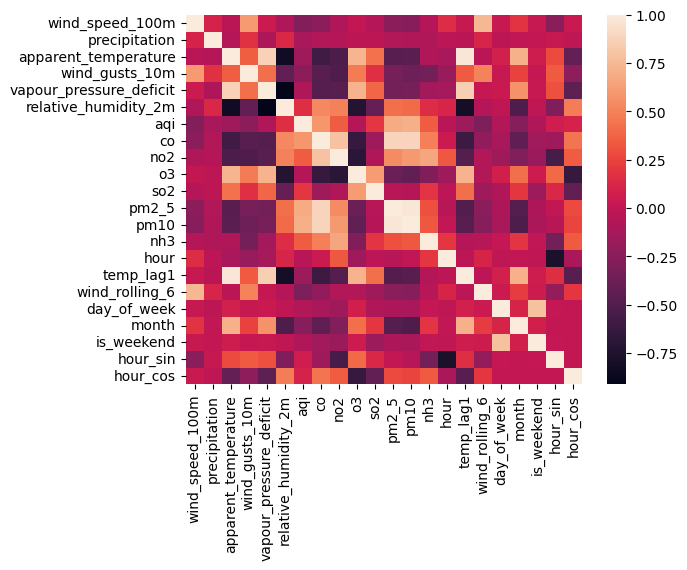

In [14]:
import seaborn as sns

data = df.corr(numeric_only=True)

# Create the heatmap
sns.heatmap(data)
plt.show()


# Precipitation vs Pm2_5

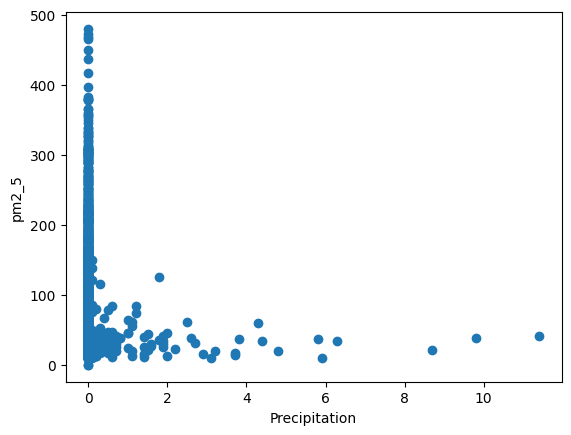

In [15]:
x = df['precipitation']
y = df['pm2_5']
plt.scatter(x,y)
plt.xlabel('Precipitation')
plt.ylabel('pm2_5')
plt.show()

# datetime vs pm2_5 

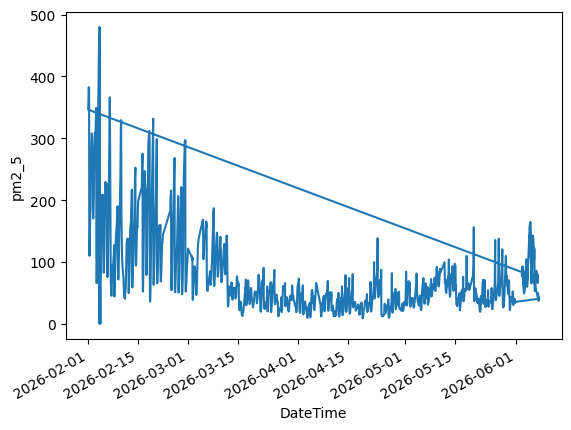

In [16]:
x = df['datetime']
y = df['pm2_5']
plt.plot(x,y)
plt.xlabel('DateTime')
plt.ylabel('pm2_5')
# This automatically rotates and formats the dates so they don't overlap!
plt.gcf().autofmt_xdate()
plt.show()

# aqi vs pm2_5

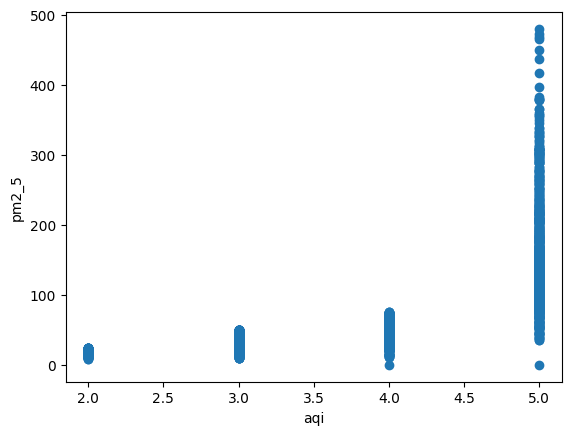

In [17]:
x = df['aqi']
y = df['pm2_5']
plt.scatter(x,y)
plt.xlabel('aqi')
plt.ylabel('pm2_5')
plt.show()